# Getting Started with Unstructured and Teradata

[Unstructured](https://unstructured.io) turns raw data from PDFs, Word documents, presentations, and more, into clean, structured output that Agents can actually use. With support for 64+ file types and 30+ connectors to enterprise systems like SharePoint, S3, and Databricks, it handles the full data preparation pipeline so your GenAI stack doesn't have to.

This notebook walks through setting up an end-to-end pipeline using the Unstructured API. We'll pull files from an S3 bucket, partition, chunk and embed them, and write the structured results into a Teradata Vantage database — ready for querying or to power downstream RAG and AI workflows.

We're using S3 as the source in this example, though Unstructured supports a wide range of [data sources](https://docs.unstructured.io/api-reference/workflow/sources/overview). The destination is a Teradata Vantage instance configured through Unstructured's [Teradata connector](https://docs.unstructured.io/api-reference/workflow/destinations/teradata-sql). For this tutorial, we'll use [Teradata ClearScape Analytics Experience](https://clearscape.teradata.com) as the Vantage environment.

## Prerequisites

Before running this notebook, make sure you have the following set up.


### Unstructured API Key

1. Sign up for free at [Unstructured](https://unstructured.io/?modal=try-for-free), or log in if you already have an account.
2. Go to the **API Keys** section in the sidebar.
3. Click **Generate API Key**, and copy it to your colab secrets.

---

### AWS S3 (Source)

You'll need:

- An **AWS access key** and **secret key**
- An **S3 bucket URI** (e.g. `s3://your-bucket/path/`)
- Files already uploaded to the bucket — PDF, DOCX, HTML, etc. See [supported file types](https://docs.unstructured.io/api-reference/supported-file-types) for the full list.

For more details, check out the [S3 source connector documentation](https://docs.unstructured.io/api-reference/workflow/sources/s3). 

---

### Teradata Vantage (Destination)

You'll need a running Teradata Vantage instance. This tutorial uses **Teradata ClearScape Analytics Experience**, a free cloud environment available at [clearscape.teradata.com](https://clearscape.teradata.com).

The destination table must exist before Unstructured writes to it. You will need the following for this notebook:

- **host**: your Teradata Vantage hostname
- **database**: name of the target database
- **user**: your Teradata username
- **password**: your Teradata password
- **table_name**: name of the destination table

> 💡 **Creating the destination table in ClearScape Analytics Experience**
>
> ClearScape Analytics Experience includes a built-in JupyterLab environment with a Teradata SQL kernel, so no separate SQL client is needed.
>
> 1. Go to [clearscape.teradata.com](https://clearscape.teradata.com) and create a free account, or sign in if you already have one.
> 2. Click **Create Environment**, give it a name, choose a region, and set a database password. Note down the password, you'll need it to connect.
> 3. Once the environment is ready, click **Run Demos Using Jupyter** to open JupyterLab.
> 4. Click the blue **+** icon in the top-left corner to open the Launcher.
> 5. Under **Notebooks**, click **Teradata SQL**.
> 6. In the first cell, run `%connect local` and enter your database password when prompted.
> 7. List the available databases and pick the one you want to use:
>
> ```sql
> SELECT DatabaseName
> FROM DBC.DatabasesV
> ORDER BY DatabaseName;
> ```
>
> 7. In a new cell, run the statement below to create the destination table, replacing `<your-database>` and `<your-table>` with your chosen names:
>
> ```sql
> CREATE SET TABLE "<your-database>"."<your-table>" (
>     "id"               VARCHAR(64) NOT NULL,
>     PRIMARY KEY ("id"),
>     "record_id"        VARCHAR(64),
>     "element_id"       VARCHAR(64),
>     "text"             VARCHAR(32000) CHARACTER SET UNICODE,
>     "type"             VARCHAR(50),
>     "embeddings"       VARCHAR(64000),
>     "last_modified"    VARCHAR(50),
>     "languages"        VARCHAR(200),
>     "file_directory"   VARCHAR(500),
>     "filename"         VARCHAR(255),
>     "filetype"         VARCHAR(50),
>     "record_locator"   VARCHAR(1000),
>     "date_created"     VARCHAR(50),
>     "date_modified"    VARCHAR(50),
>     "date_processed"   VARCHAR(50),
>     "permissions_data" VARCHAR(1000),
>     "filesize_bytes"   INTEGER,
>     "parent_id"        VARCHAR(64)
> );
> ```
>
> The `embeddings` column stores Unstructured-generated vectors as `VARCHAR(64000)` — compatible with Teradata's [Enterprise Vector Store](https://docs.teradata.com/r/Enterprise_IntelliFlex_VMware/Teradata-Vector-Store-User-Guide) after conversion to the native `VECTOR` type.

For the full list of configuration options, see the [Teradata destination documentation](https://docs.unstructured.io/api-reference/workflow/destinations/teradata-sql).

## Step 1: Install the Unstructured API Python SDK

All functionality available in the UI of the [Unstructured](https://unstructured.io/) product is also available programmatically via the API. The Unstructured API provides a set of programmatic operations that enable you to have Unstructured:

* Perform a full range of partitioning, enrichment, chunking, and embedding of your files and data, producing results that are AI-ready.
* Batch-process files locally; and batch-process files and data that are stored in remote storage locations, databases, and vector stores.

Run the following cell to install the Unstructured API Python SDK.

In [ ]:
!pip install -U "unstructured-client"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.1/68.1 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 220.2/220.2 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 333.7/333.7 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 43.9 MB/s eta 0:00:00


## Step 2: Set environment variables

Run the following cell to load your credentials from Colab Secrets.

In [ ]:
import os
from google.colab import userdata

# Unstructured
os.environ["UNSTRUCTURED_API_KEY"] = userdata.get("UNSTRUCTURED_API_KEY")

# AWS S3
os.environ["AWS_ACCESS"] = userdata.get("AWS_ACCESS")
os.environ["AWS_SECRET"] = userdata.get("AWS_SECRET")
os.environ["S3_REMOTE_URL"] = userdata.get("S3_REMOTE_URL")

# Teradata
os.environ["TERADATA_HOST"] = userdata.get("TERADATA_HOST")
os.environ["TERADATA_DATABASE"] = userdata.get("TERADATA_DATABASE")
os.environ["TERADATA_TABLENAME"] = userdata.get("TERADATA_TABLENAME")
os.environ["TERADATA_USER"] = userdata.get("TERADATA_USER")
os.environ["TERADATA_PASSWORD"] = userdata.get("TERADATA_PASSWORD")

In [ ]:
# instantiate Unstructured Client
from unstructured_client import UnstructuredClient

unstructured_client = UnstructuredClient(api_key_auth=os.environ["UNSTRUCTURED_API_KEY"])

# helper function
def pretty_print_model(response_model):
    print(response_model.model_dump_json(indent=4))

## Step 3: Create the source connector

Run the following cell to create an [S3 source connector](https://docs.unstructured.io/api-reference/workflow/sources/s3).

Your config must include:

- **`remote_url`**: the full URI to your S3 bucket or folder (e.g. `s3://your-bucket/path/`)
- **`key`**: your AWS access key
- **`secret`**: your AWS secret key
- **`recursive`**: whether to include files in subfolders

In [ ]:
from unstructured_client.models.operations import CreateSourceRequest
from unstructured_client.models.shared import CreateSourceConnector


source_response = unstructured_client.sources.create_source(
    request=CreateSourceRequest(
        create_source_connector=CreateSourceConnector(
            name="UnstructuredxTeradata Source",
            type="s3",
            config={

                # For AWS access key ID with AWS secret access key authentication:
                "key": os.environ["AWS_ACCESS"],
                "secret": os.environ["AWS_SECRET"],

                "remote_url": os.environ["S3_REMOTE_URL"],
                "recursive": True
            }
        )
    )
)

pretty_print_model(source_response.source_connector_information)

## Step 4: Create the destination connector

Run the following cell to create a Teradata destination connector.

Your config must include:

- **`host`**: the hostname of your Teradata Vantage instance
- **`database`**: the name of the target database
- **`user`**: your Teradata username
- **`password`**: your Teradata password
- **`table_name`**: the name of the destination table

For more information on other parameters, check out our [docs](https://docs.unstructured.io/api-reference/workflow/destinations/teradata-sql).

In [ ]:
from unstructured_client.models.operations import CreateDestinationRequest
from unstructured_client.models.shared import CreateDestinationConnector

destination_response = unstructured_client.destinations.create_destination(
    request=CreateDestinationRequest(
        create_destination_connector=CreateDestinationConnector(
            name="UnstructuredxTeradata Destination",
            type="teradata",
            config={
                "host": os.environ["TERADATA_HOST"],
                "database": os.environ["TERADATA_DATABASE"],
                "table_name": os.environ["TERADATA_TABLENAME"],
                "user": os.environ["TERADATA_USER"],
                "password": os.environ["TERADATA_PASSWORD"]
            }
        )
    )
)

pretty_print_model(destination_response.destination_connector_information)

## Step 5: Create the data processing workflow

This step wires everything together. We define a workflow that pulls files from S3, processes them through a sequence of transformations, and writes the structured output to Teradata.

This pipeline includes three steps:

- **Partitioner**: Converts raw files into structured elements — paragraphs, tables, titles, and more. We're using the [`vlm` strategy](https://docs.unstructured.io/api-reference/partition/document-elements) with Anthropic's Claude 4.5 Sonnet, which handles complex and layout-heavy documents well.

- **Chunking**: Splits content into smaller, query-friendly pieces using [`chunk_by_title`](https://docs.unstructured.io/api-reference/partition/chunking#%E2%80%9Dby-title%E2%80%9D-chunking-strategy), which breaks at logical section boundaries.

- **Embedding**: Generates a semantic vector for each chunk using Azure OpenAI's `text-embedding-3-large`. Learn more about [embedding options](https://docs.unstructured.io/ui/embedding).

Run the following cell to create the workflow.

In [ ]:
from unstructured_client.models.shared import (
    WorkflowNode,
    WorkflowType,
    Schedule
)

partition_node = WorkflowNode(
    name="Partitioner",
    subtype="vlm",
    type="partition",
    settings={
        "provider": "anthropic",
        "model": "claude-sonnet-4-5-20250929",
    }
)


chunk_node = WorkflowNode(
    name="Chunker",
    subtype="chunk_by_title",
    type="chunk",
    settings={
        "new_after_n_chars": 1000,
        "max_characters": 4096,
        "overlap": 150
    }
)

embedder_node = WorkflowNode(
    name='Embedder',
    subtype='azure_openai',
    type="embed",
    settings={
        'model_name': 'text-embedding-3-large'
        }
    )


response = unstructured_client.workflows.create_workflow(
    request={
        "create_workflow": {
            "name": "Teradata Destination Tutorial Workflow_",
            "source_id": source_response.source_connector_information.id,
            "destination_id": destination_response.destination_connector_information.id,
            "workflow_type": WorkflowType.CUSTOM,
            "workflow_nodes": [
                partition_node,
                chunk_node,
                embedder_node
            ]
        }
    }
)

pretty_print_model(response.workflow_information)
workflow_id = response.workflow_information.id

{
    "created_at": "2026-03-26T21:03:18.864823Z",
    "destinations": [
        "9e1efa7d-a713-4a8d-8159-12fc5e942aeb"
    ],
    "id": "facf53e6-eb0b-45fb-a55f-7841b9b7d022",
    "name": "Teradata Destination Tutorial Workflow_",
    "sources": [
        "80429692-ab02-4528-9580-4dc05005f049"
    ],
    "status": "active",
    "workflow_nodes": [
        {
            "name": "Chunker",
            "subtype": "chunk_by_title",
            "type": "chunk",
            "id": "8aa64e61-4f18-4021-8391-f7697a177f54",
            "settings": {
                "unstructured_api_url": null,
                "unstructured_api_key": null,
                "multipage_sections": false,
                "combine_text_under_n_chars": null,
                "include_orig_elements": false,
                "new_after_n_chars": 1000,
                "max_characters": 4096,
                "overlap": 150,
                "overlap_all": false,
                "contextual_chunking_strategy": null,
          

## Step 6: Run the workflow

Run the following cell to start running the workflow.

In [ ]:
res = unstructured_client.workflows.run_workflow(
    request={
        "workflow_id": workflow_id,
    }
)

pretty_print_model(res.job_information)

{
    "created_at": "2026-03-26T21:03:19.800160Z",
    "id": "4d2e6d5f-f1b1-48b6-a9f0-d283187bbe97",
    "status": "SCHEDULED",
    "workflow_id": "facf53e6-eb0b-45fb-a55f-7841b9b7d022",
    "workflow_name": "Teradata Destination Tutorial Workflow_",
    "job_type": "ephemeral"
}


## Step 7: Get the workflow run's job ID

Run the following cell to retrieve the job ID for this workflow run, which you'll use to track its status in the next step.

In [ ]:
response = unstructured_client.jobs.list_jobs(
    request={
        "workflow_id": workflow_id
    }
)

last_job = response.response_list_jobs[0]
job_id = last_job.id
print(f"job_id: {job_id}")

job_id: 4d2e6d5f-f1b1-48b6-a9f0-d283187bbe97


## Step 8: Poll for job completion

Run the following cell to poll until the job finishes. Once complete, Unstructured prints `"status": "COMPLETED"` in the job details.

In [ ]:
import time

def poll_job_status(job_id, wait_time=30):
    while True:
        response = unstructured_client.jobs.get_job(
            request={
                "job_id": job_id
            }
        )

        job = response.job_information

        if job.status == "SCHEDULED":
            print(f"Job is scheduled, polling again in {wait_time} seconds...")
            time.sleep(wait_time)
        elif job.status == "IN_PROGRESS":
            print(f"Job is in progress, polling again in {wait_time} seconds...")
            time.sleep(wait_time)
        else:
            print("Job is completed")
            break

    return job

job = poll_job_status(job_id)
pretty_print_model(job)

Job is scheduled, polling again in 30 seconds...
Job is in progress, polling again in 30 seconds...
Job is in progress, polling again in 30 seconds...
Job is in progress, polling again in 30 seconds...
Job is in progress, polling again in 30 seconds...
Job is in progress, polling again in 30 seconds...
Job is in progress, polling again in 30 seconds...
Job is in progress, polling again in 30 seconds...
Job is in progress, polling again in 30 seconds...
Job is in progress, polling again in 30 seconds...
Job is in progress, polling again in 30 seconds...
Job is completed
{
    "created_at": "2026-03-26T21:03:19.800160",
    "id": "4d2e6d5f-f1b1-48b6-a9f0-d283187bbe97",
    "status": "COMPLETED",
    "workflow_id": "facf53e6-eb0b-45fb-a55f-7841b9b7d022",
    "workflow_name": "Teradata Destination Tutorial Workflow_",
    "job_type": "ephemeral",
    "runtime": "PT5M32.8524S"
}


## Step 9: View the processed data

Once the job finishes, your documents are processed and stored in Teradata. Each row in the destination table represents a structured element from the original files — including the extracted text, element type, metadata, and embeddings.

You can query the data directly from Teradata using SQL. For example:

```sql
SELECT * FROM "DatabaseName"."TableName"
```


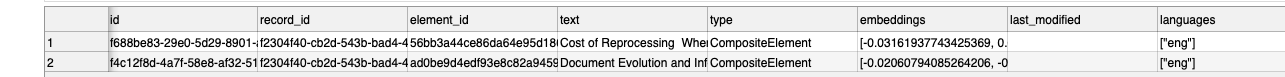